# Growth of Structure (Newtonian Limit)

In this notebook, we explore the linear growth of density perturbations in a Newtonian framework. We will solve the fluid equations for a pressure-less fluid (like cold dark matter) in an expanding background to see how cosmic expansion affects structure formation.

The evolution of the density contrast $\delta = \frac{\rho - \bar{\rho}}{\bar{\rho}}$ in the linear regime is governed by the equation:

$$ \ddot{\delta} + 2H\dot{\delta} - 4\pi G \bar{\rho}_m \delta = 0 $$

Instead of cosmic time $t$, it's more convenient to use the scale factor $a$ as the independent variable. The equation transforms into:

$$ \delta'' + \left( \frac{3}{a} + \frac{E'(a)}{E(a)} \right) \delta' - \frac{3 \Omega_{m,0}}{2 a^5 E(a)^2} \delta = 0 $$

where primes denote derivatives with respect to $a$, and $E(a) = \frac{H(a)}{H_0} = \sqrt{\Omega_{m,0} a^{-3} + \Omega_{\Lambda,0} + \Omega_{k,0} a^{-2}}$ is the normalized Hubble parameter.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

# Configure plots
plt.rcParams.update({'font.size': 14})


In [2]:
def growth_ode(a, y, Omega_m0, Omega_L0):
    # y[0] = delta, y[1] = delta'
    delta, d_delta = y
    
    # Calculate E(a) for a flat universe or open universe (ignoring Omega_k explicitly to keep it simple, but Omega_k = 1 - Om - OL)
    Omega_k0 = 1.0 - Omega_m0 - Omega_L0
    E = np.sqrt(Omega_m0 * a**-3 + Omega_L0 + Omega_k0 * a**-2)
    
    # Derivative E'(a) = dE/da
    dE = 0.5 / E * (-3 * Omega_m0 * a**-4 - 2 * Omega_k0 * a**-3)
    
    # ODE terms
    term1 = (3/a + dE/E) * d_delta
    term2 = (3 * Omega_m0) / (2 * a**5 * E**2) * delta
    
    d2_delta = -term1 + term2
    
    return [d_delta, d2_delta]


In [3]:
# Range of scale factors from matter domination to today
a_span = (0.01, 1.0)
a_eval = np.linspace(a_span[0], a_span[1], 1000)

# Initial conditions: deep in matter domination delta scales as a, so delta(a_ini) = a_ini and delta'(a_ini) = 1
y0 = [a_span[0], 1.0]

# Solve for Einstein-de Sitter (EdS, Omega_m = 1.0, Omega_L = 0)
sol_eds = solve_ivp(growth_ode, a_span, y0, args=(1.0, 0.0), t_eval=a_eval)

# Solve for Lambda-CDM (Omega_m = 0.3, Omega_L = 0.7)
sol_lcdm = solve_ivp(growth_ode, a_span, y0, args=(0.3, 0.7), t_eval=a_eval)

# Solve for an empty universe (Omega_m = 0.05, Omega_L = 0.0)
sol_empty = solve_ivp(growth_ode, a_span, y0, args=(0.05, 0.0), t_eval=a_eval)


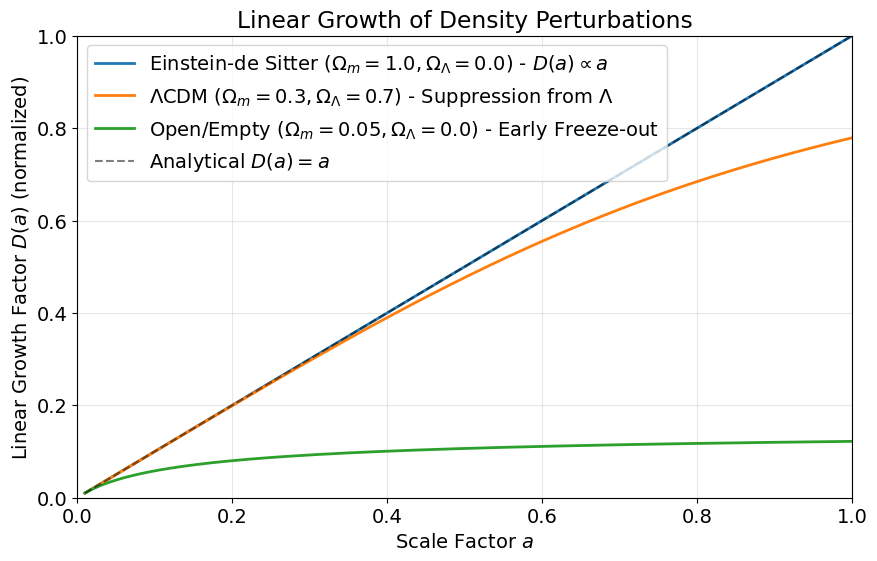

In [4]:
plt.figure(figsize=(10, 6))

# Plot the solutions, normalized to have the same initial conditions (D(a) = a initially)
plt.plot(sol_eds.t, sol_eds.y[0] / sol_eds.y[0][0] * a_span[0], label=r'Einstein-de Sitter ($\Omega_m=1.0, \Omega_\Lambda=0.0$) - $D(a) \propto a$', lw=2)
plt.plot(sol_lcdm.t, sol_lcdm.y[0] / sol_lcdm.y[0][0] * a_span[0], label=r'$\Lambda$CDM ($\Omega_m=0.3, \Omega_\Lambda=0.7$) - Suppression from $\Lambda$', lw=2)
plt.plot(sol_empty.t, sol_empty.y[0] / sol_empty.y[0][0] * a_span[0], label=r'Open/Empty ($\Omega_m=0.05, \Omega_\Lambda=0.0$) - Early Freeze-out', lw=2)

# Also plot the analytical EdS expectation to verify our numerical integration
plt.plot(a_eval, a_eval, 'k--', label=r'Analytical $D(a) = a$', alpha=0.5)

plt.xlabel(r'Scale Factor $a$')
plt.ylabel(r'Linear Growth Factor $D(a)$ (normalized)')
plt.title(r'Linear Growth of Density Perturbations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Observe how Lambda-CDM closely follows EdS while matter dominates, 
# but growth suppresses recently as Dark Energy takes over.


### Interactive Mode Growth
Below you can adjust the cosmological parameters $\Omega_m$ and $\Omega_\Lambda$, as well as advance the scale factor $a$ to observe how a single 1D density perturbation mode grows in amplitude over time for your chosen cosmology.


In [ ]:
def plot_interactive_growth(a_current, Omega_m0, Omega_L0):
    # Solve for chosen cosmology
    sol_custom = solve_ivp(growth_ode, a_span, y0, args=(Omega_m0, Omega_L0), t_eval=a_eval)
    
    # Extract the current D(a) value at scale factor a_current
    idx = np.argmin(np.abs(sol_custom.t - a_current))
    D_current = sol_custom.y[0][idx] / sol_custom.y[0][0] * a_span[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Left Plot: Growth Factor Curve ---
    ax1.plot(sol_custom.t, sol_custom.y[0] / sol_custom.y[0][0] * a_span[0], 
             label=rf'Custom ($\Omega_m={Omega_m0:.2f}, \Omega_\Lambda={Omega_L0:.2f}$)', lw=3, color='blue')
             
    # Plot baseline LCDM for reference
    ax1.plot(sol_lcdm.t, sol_lcdm.y[0] / sol_lcdm.y[0][0] * a_span[0], 
             label=r'$\Lambda$CDM ($\Omega_m=0.3, \Omega_\Lambda=0.7$)', lw=2, color='gray', linestyle='--')
             
    # Plot baseline EdS for reference
    ax1.plot(sol_eds.t, sol_eds.y[0] / sol_eds.y[0][0] * a_span[0], 
             label=r'EdS ($\Omega_m=1.0, \Omega_\Lambda=0.0$)', lw=2, color='black', linestyle=':')

    # Mark the current scale factor
    ax1.scatter([a_current], [D_current], color='red', s=100, zorder=5, label='Current Epoch')
    ax1.axvline(a_current, color='red', linestyle=':', alpha=0.5)
    
    ax1.set_xlabel(r'Scale Factor $a$')
    ax1.set_ylabel(r'Linear Growth Factor $D(a)$ (normalized)')
    ax1.set_title(r'Evolution of Growth Factor')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # --- Right Plot: 1D Density Mode ---
    x = np.linspace(0, 4 * np.pi, 200)
    k = 1.0 # arbitrary wavenumber for visualization
    delta_x = D_current * np.cos(k * x)
    
    ax2.plot(x, 1 + delta_x, color='darkorange', lw=3, label=rf'$\delta(x)$ at $a={a_current:.2f}$')
    ax2.axhline(1, color='gray', linestyle='--', alpha=0.5, label=r'Background Density $\bar{\rho}$')
    
    ax2.set_xlabel(r'Comoving Coordinate $x$')
    ax2.set_ylabel(r'Density $\rho / \bar{\rho} = 1 + \delta$')
    ax2.set_title(r'Growth of a Single Mode')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 2)
    ax2.set_xticks([]) # Hide arbitrary spatial ticks
    
    plt.tight_layout()
    plt.show()

# Create interactive widgets
style = {'description_width': 'initial'}
a_slider = widgets.FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description=r'Scale Factor $a$:', style=style, readout_format='.2f')
om_slider = widgets.FloatSlider(value=0.3, min=0.05, max=1.5, step=0.05, description=r'$\Omega_m$:', style=style)
ol_slider = widgets.FloatSlider(value=0.7, min=0.0, max=1.5, step=0.05, description=r'$\Omega_\Lambda$:', style=style)

widgets.interact(plot_interactive_growth, a_current=a_slider, Omega_m0=om_slider, Omega_L0=ol_slider);


interactive(children=(FloatSlider(value=0.5, description='Scale Factor $a$:', max=1.0, min=0.01, step=0.01, st…

### Discussion
Notice how the presence of Dark Energy ($\Omega_\Lambda=0.7$) suppresses the growth of structure relative to a purely matter-dominated Einstein-de Sitter universe. This is because Dark Energy causes the universe to rapidly expand, pulling matter apart faster than gravity can herd it together. Because of this, structure formation essentially "freezes out" in the very late universe. 

An open, mostly empty universe freezes out even earlier, because the expansion is not significantly slowed by the gravitating matter density.
